Name - Bhushan Mandekar

Assignment - Supervised ML

a) Describe the working of a Decision Tree algorithm. How does it decide on the best features to split the data? What are some advantages and disadvantages of using Decision Trees?

**Decision Tree Algorithm**

A Decision Tree is a supervised machine learning algorithm used for both classification and regression tasks. It represents decisions and their possible outcomes in the form of a tree-like structure. The algorithm starts with the entire dataset at the root node and repeatedly splits the data into smaller subsets based on feature values. Each internal node represents a test on a feature, each branch represents the outcome of the test, and each leaf node represents the final prediction or class label.

**How Does a Decision Tree Select the Best Feature?**

The Decision Tree chooses the feature that best separates the data into distinct classes. It evaluates all available features and selects the one that produces the purest subsets. Common measures used for feature selection are:

1. **Information Gain (Entropy):** Measures the reduction in uncertainty after splitting the data.
2. **Gini Impurity:** Measures the probability of incorrectly classifying a randomly chosen element.

The feature with the highest Information Gain or the lowest Gini Impurity is selected for splitting. This process is repeated recursively until a stopping criterion is met, such as reaching a maximum depth or obtaining pure leaf nodes.

**Advantages of Decision Trees**

1. Easy to understand and interpret.
2. Requires minimal data preprocessing.
3. Can handle both numerical and categorical data.
4. Suitable for both classification and regression problems.
5. Provides clear decision rules and feature importance.

**Disadvantages of Decision Trees**

1. Prone to overfitting, especially with complex trees.
2. Sensitive to small changes in the training data.
3. Can become difficult to interpret when the tree is very large.
4. May not provide the highest predictive accuracy compared to ensemble methods.
5. Can be biased toward features with many distinct values.

**Conclusion**

Decision Trees are simple and powerful machine learning algorithms that make predictions by recursively splitting data based on the most informative features. Their interpretability and ease of use make them popular; however, they require proper tuning to avoid overfitting and improve generalization.


b) Use the Life Expectancy Prediction dataset from below Kaggle link and create an end to end project on Jupyter/Colab.

https://www.kaggle.com/datasets/vikramamin/life-expectancy-who/data


i. Download the dataset from above link and load it into your Python environment.

ii. Perform the EDA and do the visualizations.

iii. Check the distributions/skewness in the variables and do the transformations if required.

iv. Check/Treat the outliers and do the feature scaling if required.

v. Create a ML model to predict the life expectancy based on the specifications given.

vi. Check for overfitting and treat them accordingly.

vii. Use all the Supervised ML algorithms (DT, RF, SVM, XGBoost etc.) and compare the performances to get the best model.

In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.svm import SVR

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

Load Dataset

In [2]:
df = pd.read_csv("Life Expectancy Data.csv")
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [3]:
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   str    
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   str    
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio                          

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.000000,2928.000000,2928.000000,2938.000000,2744.000000,2938.000000,2385.000000,2938.000000,2904.000000,2938.000000,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2775.000000
mean,2007.518720,69.224932,164.796448,30.303948,4.602861,738.251295,80.940461,2419.592240,38.321247,42.035739,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,0.627551,11.992793
std,4.613841,9.523867,124.292079,117.926501,4.052413,1987.914858,25.070016,11467.272489,20.044034,160.445548,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,0.210904,3.358920
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.100000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,19.300000,0.000000,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,0.493000,10.100000
50%,2008.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.000000,75.700000,228.000000,22.000000,7.702500,441.534144,97.000000,360.250000,56.200000,28.000000,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,0.779000,14.300000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.60000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


Data Cleaning

In [4]:
df.isnull().sum()

Country                              0
Year                                 0
Status                               0
Life expectancy                     10
Adult Mortality                     10
infant deaths                        0
Alcohol                            194
percentage expenditure               0
Hepatitis B                        553
Measles                              0
 BMI                                34
under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
 HIV/AIDS                            0
GDP                                448
Population                         652
 thinness  1-19 years               34
 thinness 5-9 years                 34
Income composition of resources    167
Schooling                          163
dtype: int64

In [5]:
df.dtypes


Country                                str
Year                                 int64
Status                                 str
Life expectancy                    float64
Adult Mortality                    float64
infant deaths                        int64
Alcohol                            float64
percentage expenditure             float64
Hepatitis B                        float64
Measles                              int64
 BMI                               float64
under-five deaths                    int64
Polio                              float64
Total expenditure                  float64
Diphtheria                         float64
 HIV/AIDS                          float64
GDP                                float64
Population                         float64
 thinness  1-19 years              float64
 thinness 5-9 years                float64
Income composition of resources    float64
Schooling                          float64
dtype: object

In [6]:
import numpy as np

# Numerical columns only
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Categorical columns
cat_cols = df.select_dtypes(exclude=np.number).columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [7]:
df.isnull().sum()

Country                            0
Year                               0
Status                             0
Life expectancy                    0
Adult Mortality                    0
infant deaths                      0
Alcohol                            0
percentage expenditure             0
Hepatitis B                        0
Measles                            0
 BMI                               0
under-five deaths                  0
Polio                              0
Total expenditure                  0
Diphtheria                         0
 HIV/AIDS                          0
GDP                                0
Population                         0
 thinness  1-19 years              0
 thinness 5-9 years                0
Income composition of resources    0
Schooling                          0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.drop_duplicates(inplace=True)

Exploratory Data Analysis (EDA)

Correlation Heatmap

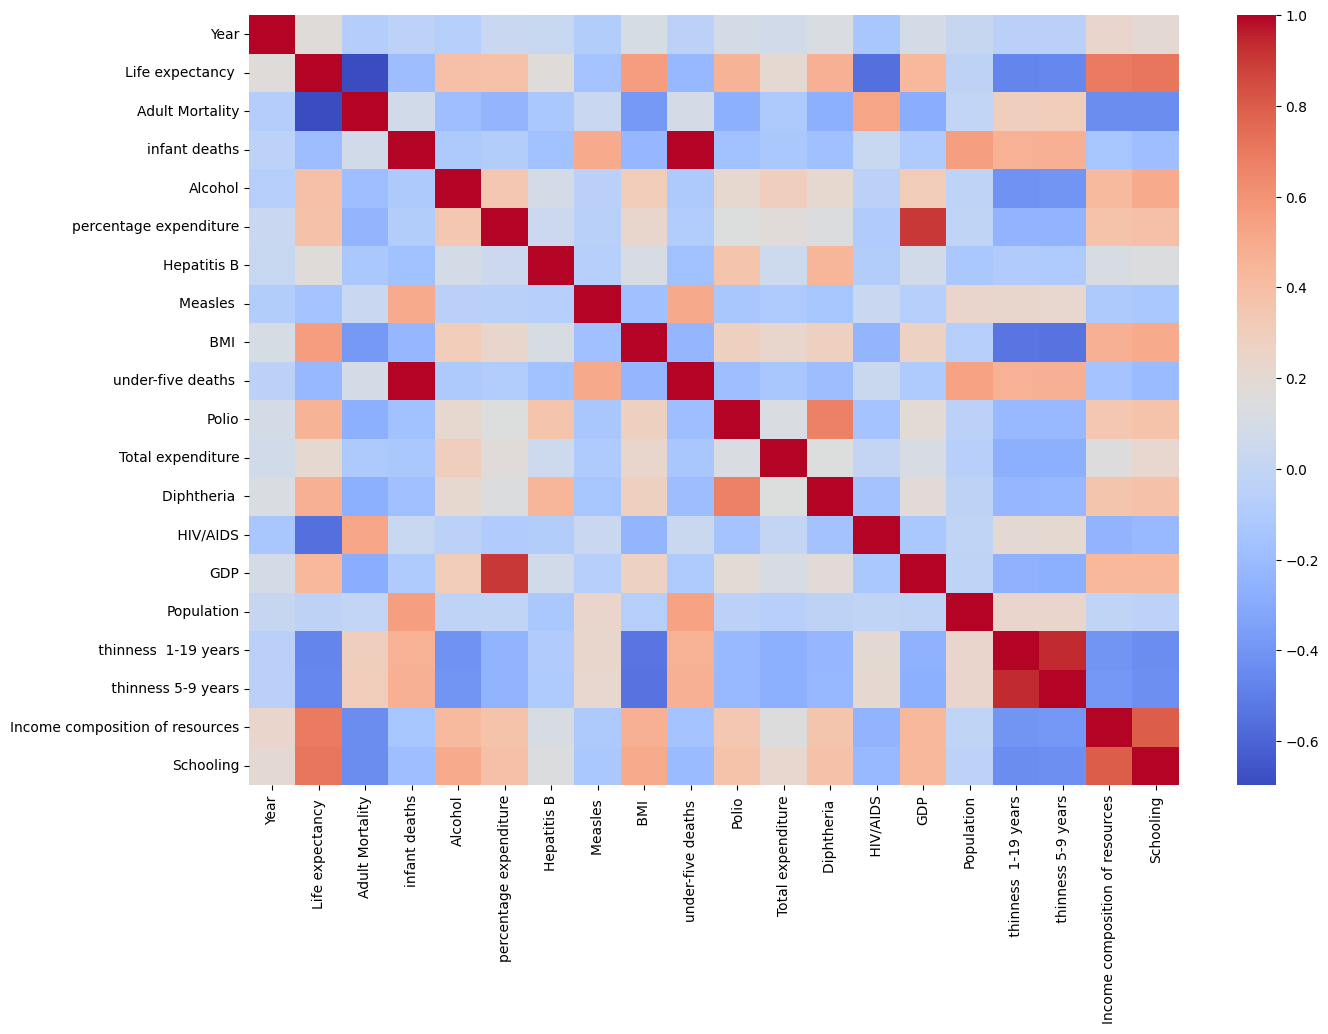

In [10]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(numeric_only=True),
            cmap='coolwarm')
plt.show()

Distribution of Life Expectancy

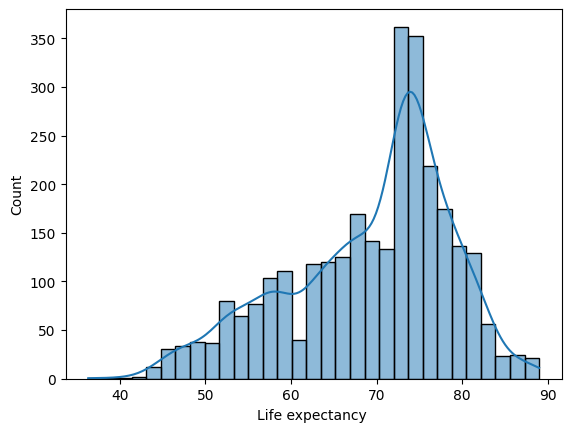

In [11]:
sns.histplot(df['Life expectancy '], kde=True)
plt.show()

Boxplot

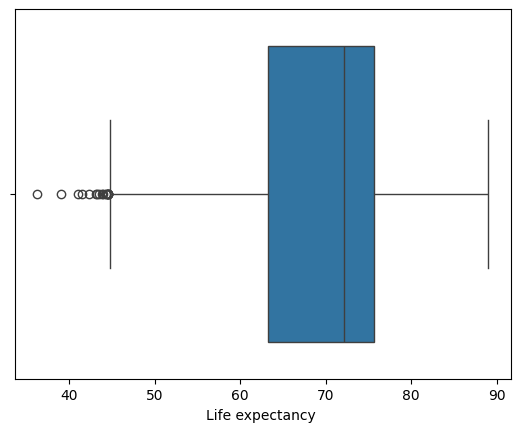

In [12]:
sns.boxplot(x=df['Life expectancy '])
plt.show()

Pairplot

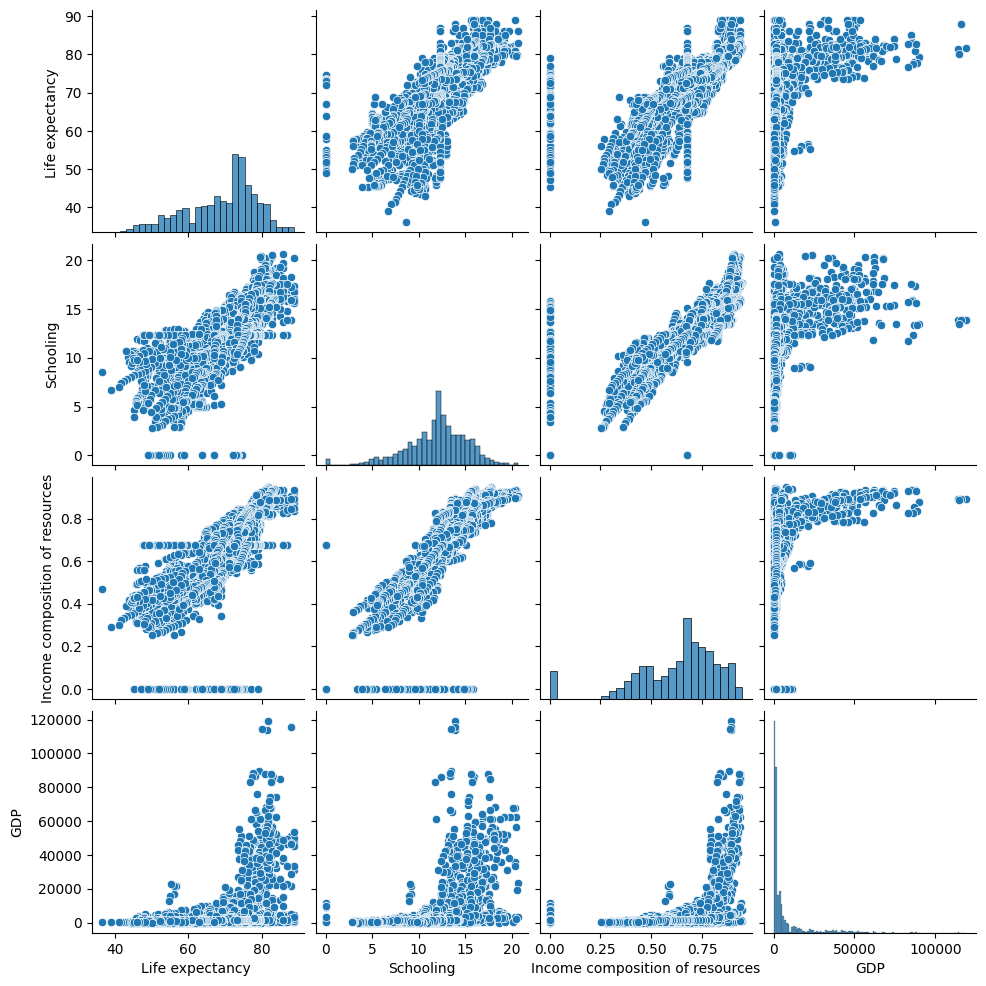

In [13]:
sns.pairplot(df[['Life expectancy ',
                 'Schooling',
                 'Income composition of resources',
                 'GDP']])
plt.show()

Check Skewness

In [14]:
numeric_cols=df.select_dtypes(include=np.number)

numeric_cols.skew().sort_values(ascending=False)

Population                         17.972837
infant deaths                       9.786963
under-five deaths                   9.495065
Measles                             9.441332
 HIV/AIDS                           5.396112
percentage expenditure              4.652051
GDP                                 3.543756
 thinness 5-9 years                 1.795694
 thinness  1-19 years               1.729496
Adult Mortality                     1.177899
Total expenditure                   0.661108
Alcohol                             0.649578
Year                               -0.006409
 BMI                               -0.229157
Schooling                          -0.635052
Life expectancy                    -0.642391
Income composition of resources    -1.212526
Diphtheria                         -2.083566
Polio                              -2.108909
Hepatitis B                        -2.281697
dtype: float64

Log Transformation

In [15]:
df['GDP']=np.log1p(df['GDP'])

In [16]:
df['Population']=np.log1p(df['Population'])

In [17]:
df[['GDP','Population']].skew()

GDP          -0.155021
Population   -0.701011
dtype: float64

Encode Categorical Variables

In [18]:
df=pd.get_dummies(df,
                  columns=['Country','Status'],
                  drop_first=True)

Outlier Treatment

IQR Method

In [19]:

# Convert boolean columns created by get_dummies()

bool_cols = df.select_dtypes(include='bool').columns

df[bool_cols] = df[bool_cols].astype(int)

# Check datatypes
print(df.dtypes.value_counts())

# Select only numerical columns
# ---------------------------------------------------
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Calculate Q1, Q3 and IQR

Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)

IQR = Q3 - Q1

# Count outliers before treatme

outliers = ((df[num_cols] < (Q1 - 1.5 * IQR)) |
            (df[num_cols] > (Q3 + 1.5 * IQR)))

print("Outliers before treatment:")
print(outliers.sum().sort_values(ascending=False))

# Cap outliers using IQR method

for col in num_cols:

    lower_bound = Q1[col] - 1.5 * IQR[col]
    upper_bound = Q3[col] + 1.5 * IQR[col]

    df[col] = np.where(df[col] < lower_bound,
                       lower_bound,
                       df[col])

    df[col] = np.where(df[col] > upper_bound,
                       upper_bound,
                       df[col])


# Verify outliers after treatment

Q1_new = df[num_cols].quantile(0.25)
Q3_new = df[num_cols].quantile(0.75)

IQR_new = Q3_new - Q1_new

outliers_after = ((df[num_cols] < (Q1_new - 1.5 * IQR_new)) |
                  (df[num_cols] > (Q3_new + 1.5 * IQR_new)))

print("\nOutliers after treatment:")
print(outliers_after.sum().sort_values(ascending=False))

print("\nOutlier treatment completed successfully.")

int64      197
float64     16
Name: count, dtype: int64
Outliers before treatment:
Measles                   542
 HIV/AIDS                 542
Status_Developing         512
under-five deaths         394
percentage expenditure    389
                         ... 
Country_Monaco              1
Country_San Marino          1
Country_Tuvalu              1
Year                        0
 BMI                        0
Length: 213, dtype: int64

Outliers after treatment:
Year                 0
Life expectancy      0
Adult Mortality      0
infant deaths        0
Alcohol              0
                    ..
Country_Viet Nam     0
Country_Yemen        0
Country_Zambia       0
Country_Zimbabwe     0
Status_Developing    0
Length: 213, dtype: int64

Outlier treatment completed successfully.


Feature Selection

In [20]:
X=df.drop('Life expectancy ',axis=1)

y=df['Life expectancy ']

Train-Test Split

In [21]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42)

Feature Scaling

In [22]:
scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

Model Building

Linear Regression

In [23]:
lr=LinearRegression()

lr.fit(X_train,y_train)

pred_lr=lr.predict(X_test)

Decision Tree

In [24]:
dt=DecisionTreeRegressor(
    max_depth=5,
    random_state=42)

dt.fit(X_train,y_train)

pred_dt=dt.predict(X_test)

Random Forest

In [25]:
rf=RandomForestRegressor(
    n_estimators=200,
    random_state=42)

rf.fit(X_train,y_train)

pred_rf=rf.predict(X_test)

Support Vector Machine

In [26]:
svr=SVR()

svr.fit(X_train_scaled,y_train)

pred_svr=svr.predict(X_test_scaled)

XGBoost

In [27]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [28]:
from xgboost import XGBRegressor

xgb=XGBRegressor()

xgb.fit(X_train,y_train)

pred_xgb=xgb.predict(X_test)

Model Evaluation Function

In [29]:
def evaluate(y_test,pred):

    mae=mean_absolute_error(y_test,pred)

    rmse=np.sqrt(
        mean_squared_error(y_test,pred))

    r2=r2_score(y_test,pred)

    return [mae,rmse,r2]

Compare Models

In [30]:
results=pd.DataFrame({

'Model':['Linear Regression',
         'Decision Tree',
         'Random Forest',
         'SVM',
         'XGBoost'],

'MAE':[evaluate(y_test,pred_lr)[0],
       evaluate(y_test,pred_dt)[0],
       evaluate(y_test,pred_rf)[0],
       evaluate(y_test,pred_svr)[0],
       evaluate(y_test,pred_xgb)[0]],

'RMSE':[evaluate(y_test,pred_lr)[1],
        evaluate(y_test,pred_dt)[1],
        evaluate(y_test,pred_rf)[1],
        evaluate(y_test,pred_svr)[1],
        evaluate(y_test,pred_xgb)[1]],

'R2':[evaluate(y_test,pred_lr)[2],
      evaluate(y_test,pred_dt)[2],
      evaluate(y_test,pred_rf)[2],
      evaluate(y_test,pred_svr)[2],
      evaluate(y_test,pred_xgb)[2]]
})

results.sort_values('R2',
                    ascending=False)

,Model,MAE,RMSE,R2
2,Random Forest,1.099684,1.684558,0.967209
4,XGBoost,1.160618,1.713848,0.966059
1,Decision Tree,2.115243,2.807753,0.908905
3,SVM,2.033408,2.856914,0.905687
0,Linear Regression,2.688669,3.521928,0.856669


Check Overfitting

In [31]:
print("Train Score:",
      rf.score(X_train,y_train))

print("Test Score:",
      rf.score(X_test,y_test))

Train Score: 0.9945305888629306
Test Score: 0.9672093417888763


Treatment of Overfitting
For Decision Tree:

In [32]:
DecisionTreeRegressor(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5
)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_l

For Random Forest:

In [33]:
RandomForestRegressor(
    n_estimators=200,
    max_depth=10
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

Use Cross Validation:

In [34]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring='r2')

print(scores.mean())

0.9064966778954846


In [35]:
import joblib
joblib.dump(rf,'life_expectancy_model.pkl')
joblib.dump(scaler,'scaler.pkl')

['scaler.pkl']

In [36]:
print(scaler.n_features_in_)

212


In [37]:
print(X.columns.tolist())

['Year', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 'Total expenditure', 'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population', ' thinness  1-19 years', ' thinness 5-9 years', 'Income composition of resources', 'Schooling', 'Country_Albania', 'Country_Algeria', 'Country_Angola', 'Country_Antigua and Barbuda', 'Country_Argentina', 'Country_Armenia', 'Country_Australia', 'Country_Austria', 'Country_Azerbaijan', 'Country_Bahamas', 'Country_Bahrain', 'Country_Bangladesh', 'Country_Barbados', 'Country_Belarus', 'Country_Belgium', 'Country_Belize', 'Country_Benin', 'Country_Bhutan', 'Country_Bolivia (Plurinational State of)', 'Country_Bosnia and Herzegovina', 'Country_Botswana', 'Country_Brazil', 'Country_Brunei Darussalam', 'Country_Bulgaria', 'Country_Burkina Faso', 'Country_Burundi', 'Country_Cabo Verde', 'Country_Cambodia', 'Country_Cameroon', 'Country_Canada', 'Country_Central African Republic', '

b) Use the Life Expectancy Prediction dataset from below Kaggle link and create an end to end project on Jupyter/Colab.

https://www.kaggle.com/datasets/vikramamin/life-expectancy-who/data


i. Download the dataset from above link and load it into your Python environment.

ii. Perform the EDA and do the visualizations.

iii. Check the distributions/skewness in the variables and do the transformations if required.

iv. Check/Treat the outliers and do the feature scaling if required.

v. Create a ML model to predict the life expectancy based on the specifications given.

vi. Check for overfitting and treat them accordingly.

vii. Use all the Supervised ML algorithms (DT, RF, SVM, XGBoost etc.) and compare the performances to get the best model.

In [38]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.svm import SVR

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

Load Dataset

In [39]:
df = pd.read_csv("Life Expectancy Data.csv")
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [40]:
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   str    
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   str    
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio                          

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.000000,2928.000000,2928.000000,2938.000000,2744.000000,2938.000000,2385.000000,2938.000000,2904.000000,2938.000000,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2775.000000
mean,2007.518720,69.224932,164.796448,30.303948,4.602861,738.251295,80.940461,2419.592240,38.321247,42.035739,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,0.627551,11.992793
std,4.613841,9.523867,124.292079,117.926501,4.052413,1987.914858,25.070016,11467.272489,20.044034,160.445548,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,0.210904,3.358920
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.100000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,19.300000,0.000000,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,0.493000,10.100000
50%,2008.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.000000,75.700000,228.000000,22.000000,7.702500,441.534144,97.000000,360.250000,56.200000,28.000000,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,0.779000,14.300000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.60000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


Data Cleaning

In [41]:
df.isnull().sum()

Country                              0
Year                                 0
Status                               0
Life expectancy                     10
Adult Mortality                     10
infant deaths                        0
Alcohol                            194
percentage expenditure               0
Hepatitis B                        553
Measles                              0
 BMI                                34
under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
 HIV/AIDS                            0
GDP                                448
Population                         652
 thinness  1-19 years               34
 thinness 5-9 years                 34
Income composition of resources    167
Schooling                          163
dtype: int64

In [42]:
df.dtypes


Country                                str
Year                                 int64
Status                                 str
Life expectancy                    float64
Adult Mortality                    float64
infant deaths                        int64
Alcohol                            float64
percentage expenditure             float64
Hepatitis B                        float64
Measles                              int64
 BMI                               float64
under-five deaths                    int64
Polio                              float64
Total expenditure                  float64
Diphtheria                         float64
 HIV/AIDS                          float64
GDP                                float64
Population                         float64
 thinness  1-19 years              float64
 thinness 5-9 years                float64
Income composition of resources    float64
Schooling                          float64
dtype: object

In [43]:
import numpy as np

# Numerical columns only
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Categorical columns
cat_cols = df.select_dtypes(exclude=np.number).columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [44]:
df.isnull().sum()

Country                            0
Year                               0
Status                             0
Life expectancy                    0
Adult Mortality                    0
infant deaths                      0
Alcohol                            0
percentage expenditure             0
Hepatitis B                        0
Measles                            0
 BMI                               0
under-five deaths                  0
Polio                              0
Total expenditure                  0
Diphtheria                         0
 HIV/AIDS                          0
GDP                                0
Population                         0
 thinness  1-19 years              0
 thinness 5-9 years                0
Income composition of resources    0
Schooling                          0
dtype: int64

In [45]:
df.duplicated().sum()

np.int64(0)

In [46]:
df.drop_duplicates(inplace=True)

Exploratory Data Analysis (EDA)

Correlation Heatmap

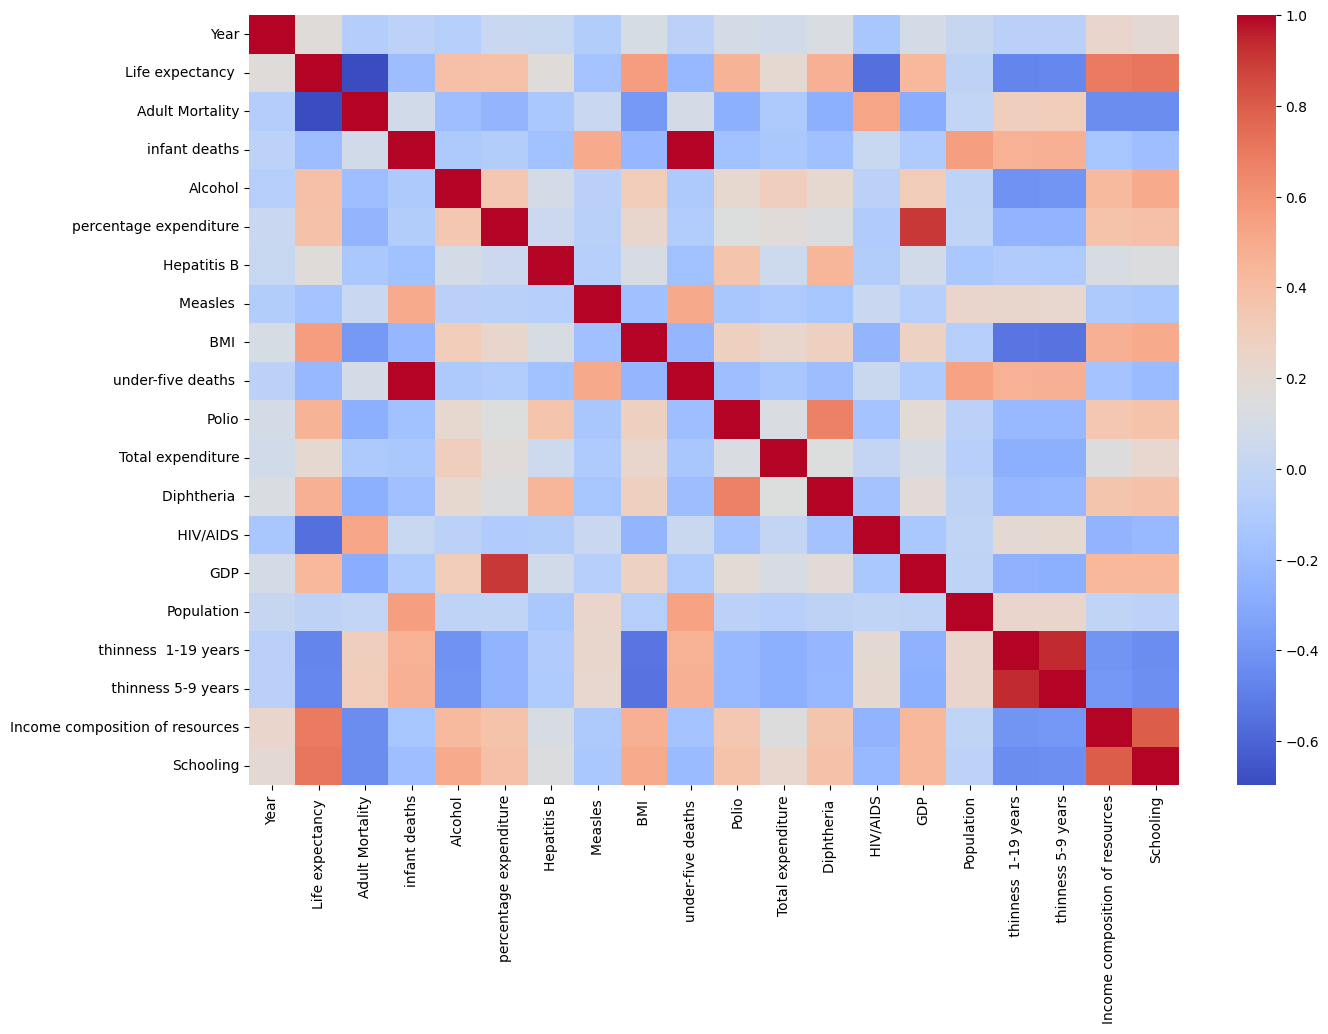

In [47]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(numeric_only=True),
            cmap='coolwarm')
plt.show()

Distribution of Life Expectancy

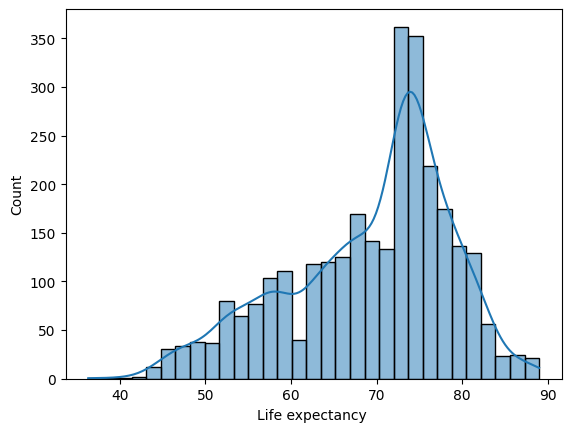

In [48]:
sns.histplot(df['Life expectancy '], kde=True)
plt.show()

Boxplot

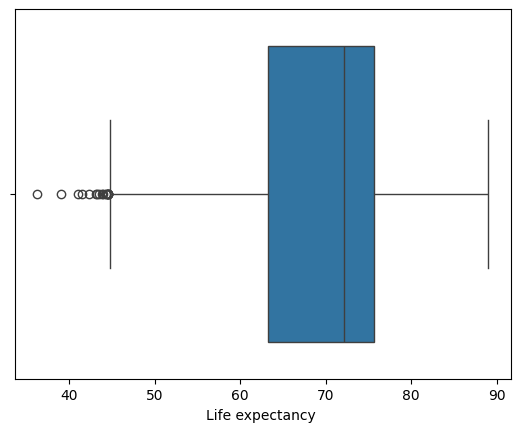

In [49]:
sns.boxplot(x=df['Life expectancy '])
plt.show()

Pairplot

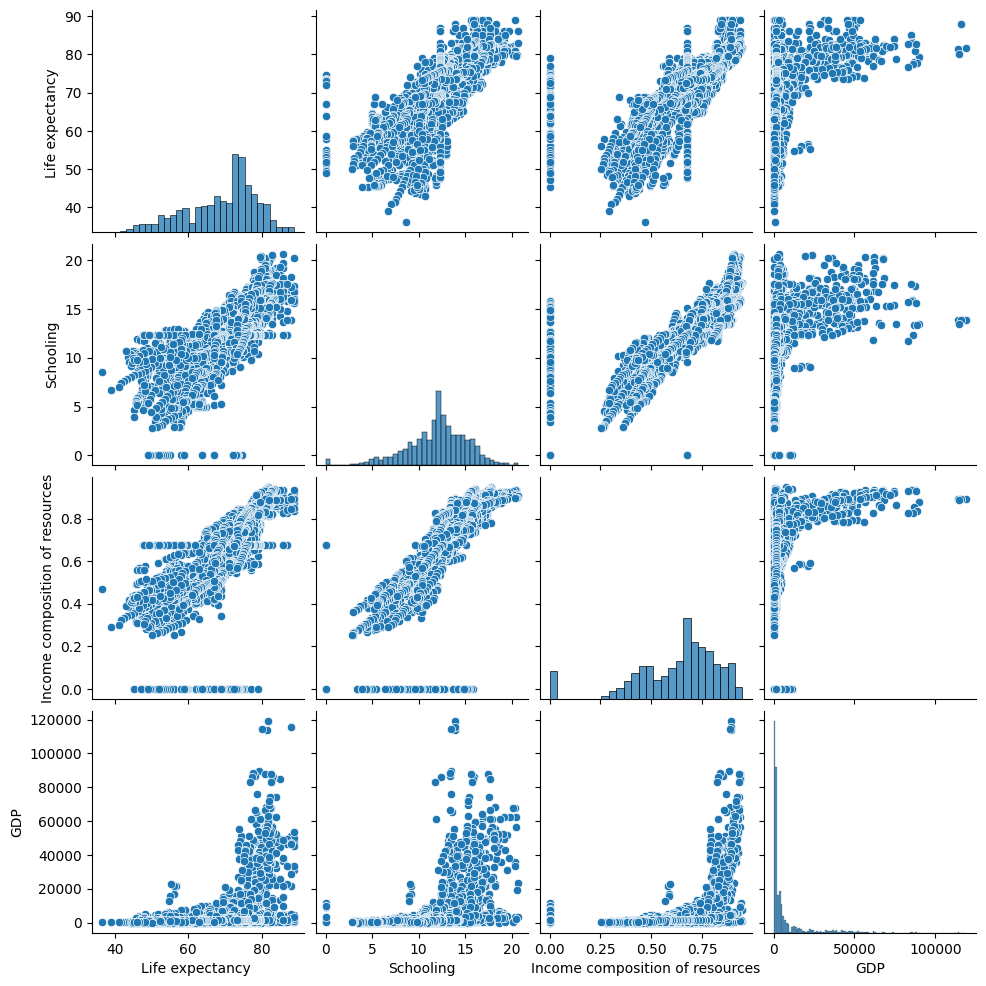

In [50]:
sns.pairplot(df[['Life expectancy ',
                 'Schooling',
                 'Income composition of resources',
                 'GDP']])
plt.show()

Check Skewness

In [51]:
numeric_cols=df.select_dtypes(include=np.number)

numeric_cols.skew().sort_values(ascending=False)

Population                         17.972837
infant deaths                       9.786963
under-five deaths                   9.495065
Measles                             9.441332
 HIV/AIDS                           5.396112
percentage expenditure              4.652051
GDP                                 3.543756
 thinness 5-9 years                 1.795694
 thinness  1-19 years               1.729496
Adult Mortality                     1.177899
Total expenditure                   0.661108
Alcohol                             0.649578
Year                               -0.006409
 BMI                               -0.229157
Schooling                          -0.635052
Life expectancy                    -0.642391
Income composition of resources    -1.212526
Diphtheria                         -2.083566
Polio                              -2.108909
Hepatitis B                        -2.281697
dtype: float64

Log Transformation

In [52]:
df['GDP']=np.log1p(df['GDP'])

In [53]:
df['Population']=np.log1p(df['Population'])

In [54]:
df[['GDP','Population']].skew()

GDP          -0.155021
Population   -0.701011
dtype: float64

Encode Categorical Variables

In [55]:
df=pd.get_dummies(df,
                  columns=['Country','Status'],
                  drop_first=True)

Outlier Treatment

IQR Method

In [56]:

# Convert boolean columns created by get_dummies()

bool_cols = df.select_dtypes(include='bool').columns

df[bool_cols] = df[bool_cols].astype(int)

# Check datatypes
print(df.dtypes.value_counts())

# Select only numerical columns
# ---------------------------------------------------
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Calculate Q1, Q3 and IQR

Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)

IQR = Q3 - Q1

# Count outliers before treatme

outliers = ((df[num_cols] < (Q1 - 1.5 * IQR)) |
            (df[num_cols] > (Q3 + 1.5 * IQR)))

print("Outliers before treatment:")
print(outliers.sum().sort_values(ascending=False))

# Cap outliers using IQR method

for col in num_cols:

    lower_bound = Q1[col] - 1.5 * IQR[col]
    upper_bound = Q3[col] + 1.5 * IQR[col]

    df[col] = np.where(df[col] < lower_bound,
                       lower_bound,
                       df[col])

    df[col] = np.where(df[col] > upper_bound,
                       upper_bound,
                       df[col])


# Verify outliers after treatment

Q1_new = df[num_cols].quantile(0.25)
Q3_new = df[num_cols].quantile(0.75)

IQR_new = Q3_new - Q1_new

outliers_after = ((df[num_cols] < (Q1_new - 1.5 * IQR_new)) |
                  (df[num_cols] > (Q3_new + 1.5 * IQR_new)))

print("\nOutliers after treatment:")
print(outliers_after.sum().sort_values(ascending=False))

print("\nOutlier treatment completed successfully.")

int64      197
float64     16
Name: count, dtype: int64
Outliers before treatment:
Measles                   542
 HIV/AIDS                 542
Status_Developing         512
under-five deaths         394
percentage expenditure    389
                         ... 
Country_Monaco              1
Country_San Marino          1
Country_Tuvalu              1
Year                        0
 BMI                        0
Length: 213, dtype: int64

Outliers after treatment:
Year                 0
Life expectancy      0
Adult Mortality      0
infant deaths        0
Alcohol              0
                    ..
Country_Viet Nam     0
Country_Yemen        0
Country_Zambia       0
Country_Zimbabwe     0
Status_Developing    0
Length: 213, dtype: int64

Outlier treatment completed successfully.


Feature Selection

In [57]:
X=df.drop('Life expectancy ',axis=1)

y=df['Life expectancy ']

Train-Test Split

In [58]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42)

Feature Scaling

In [59]:
scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

Model Building

Linear Regression

In [60]:
lr=LinearRegression()

lr.fit(X_train,y_train)

pred_lr=lr.predict(X_test)

Decision Tree

In [61]:
dt=DecisionTreeRegressor(
    max_depth=5,
    random_state=42)

dt.fit(X_train,y_train)

pred_dt=dt.predict(X_test)

Random Forest

In [62]:
rf=RandomForestRegressor(
    n_estimators=200,
    random_state=42)

rf.fit(X_train,y_train)

pred_rf=rf.predict(X_test)

Support Vector Machine

In [63]:
svr=SVR()

svr.fit(X_train_scaled,y_train)

pred_svr=svr.predict(X_test_scaled)

XGBoost

In [64]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [65]:
from xgboost import XGBRegressor

xgb=XGBRegressor()

xgb.fit(X_train,y_train)

pred_xgb=xgb.predict(X_test)

Model Evaluation Function

In [66]:
def evaluate(y_test,pred):

    mae=mean_absolute_error(y_test,pred)

    rmse=np.sqrt(
        mean_squared_error(y_test,pred))

    r2=r2_score(y_test,pred)

    return [mae,rmse,r2]

Compare Models

In [67]:
results=pd.DataFrame({

'Model':['Linear Regression',
         'Decision Tree',
         'Random Forest',
         'SVM',
         'XGBoost'],

'MAE':[evaluate(y_test,pred_lr)[0],
       evaluate(y_test,pred_dt)[0],
       evaluate(y_test,pred_rf)[0],
       evaluate(y_test,pred_svr)[0],
       evaluate(y_test,pred_xgb)[0]],

'RMSE':[evaluate(y_test,pred_lr)[1],
        evaluate(y_test,pred_dt)[1],
        evaluate(y_test,pred_rf)[1],
        evaluate(y_test,pred_svr)[1],
        evaluate(y_test,pred_xgb)[1]],

'R2':[evaluate(y_test,pred_lr)[2],
      evaluate(y_test,pred_dt)[2],
      evaluate(y_test,pred_rf)[2],
      evaluate(y_test,pred_svr)[2],
      evaluate(y_test,pred_xgb)[2]]
})

results.sort_values('R2',
                    ascending=False)

,Model,MAE,RMSE,R2
2,Random Forest,1.099684,1.684558,0.967209
4,XGBoost,1.160618,1.713848,0.966059
1,Decision Tree,2.115243,2.807753,0.908905
3,SVM,2.033408,2.856914,0.905687
0,Linear Regression,2.688669,3.521928,0.856669


Check Overfitting

In [68]:
print("Train Score:",
      rf.score(X_train,y_train))

print("Test Score:",
      rf.score(X_test,y_test))

Train Score: 0.9945305888629306
Test Score: 0.9672093417888763


Treatment of Overfitting
For Decision Tree:

In [69]:
DecisionTreeRegressor(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5
)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_l

For Random Forest:

In [70]:
RandomForestRegressor(
    n_estimators=200,
    max_depth=10
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

Use Cross Validation:

In [71]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring='r2')

print(scores.mean())

0.9064966778954846


In [72]:
import joblib

joblib.dump(rf, "life_expectancy_model.pkl", compress=3)
joblib.dump(scaler, "scaler.pkl")
joblib.dump(X.columns.tolist(), "feature_names.pkl")

print("Files saved successfully!")

Files saved successfully!


In [73]:
print(X.columns.tolist())

['Year', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 'Total expenditure', 'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population', ' thinness  1-19 years', ' thinness 5-9 years', 'Income composition of resources', 'Schooling', 'Country_Albania', 'Country_Algeria', 'Country_Angola', 'Country_Antigua and Barbuda', 'Country_Argentina', 'Country_Armenia', 'Country_Australia', 'Country_Austria', 'Country_Azerbaijan', 'Country_Bahamas', 'Country_Bahrain', 'Country_Bangladesh', 'Country_Barbados', 'Country_Belarus', 'Country_Belgium', 'Country_Belize', 'Country_Benin', 'Country_Bhutan', 'Country_Bolivia (Plurinational State of)', 'Country_Bosnia and Herzegovina', 'Country_Botswana', 'Country_Brazil', 'Country_Brunei Darussalam', 'Country_Bulgaria', 'Country_Burkina Faso', 'Country_Burundi', 'Country_Cabo Verde', 'Country_Cambodia', 'Country_Cameroon', 'Country_Canada', 'Country_Central African Republic', '

In [74]:
import joblib

model = joblib.load("life_expectancy_model.pkl")
print(type(model))
print(model.n_features_in_)

<class 'sklearn.ensemble._forest.RandomForestRegressor'>
212


d) What is the difference between Bagging Classifier and voting classifier. Explain the working of both the algorithms.

Bagging Classifier and Voting Classifier are ensemble learning techniques used to improve the performance and accuracy of machine learning models. However, they differ in the way they combine multiple classifiers.

Difference Between Bagging Classifier and Voting Classifier:

1. Bagging (Bootstrap Aggregating) uses multiple models of the same type, whereas Voting Classifier can use different types of models.
2. In Bagging, each model is trained on a different bootstrap sample of the training data. In Voting, all models are trained on the same dataset.
3. Bagging mainly aims to reduce variance and prevent overfitting, while Voting aims to improve prediction accuracy by combining the strengths of different models.
4. Random Forest is a common example of Bagging, whereas a combination of Logistic Regression, Decision Tree, and Support Vector Machine (SVM) is an example of a Voting Classifier.

Working of Bagging Classifier:

Bagging, short for Bootstrap Aggregating, is an ensemble technique in which multiple training datasets are created by randomly sampling the original dataset with replacement. A separate classifier is trained on each dataset. During prediction, each classifier gives its output, and the final prediction is determined through majority voting.

Steps:
1. Create multiple bootstrap samples from the original dataset.
2. Train a separate classifier on each sample.
3. Obtain predictions from all classifiers.
4. Combine the predictions using majority voting.
5. The class receiving the highest number of votes is selected as the final output.

Advantages:
- Reduces overfitting.
- Improves model stability.
- Increases prediction accuracy.

Working of Voting Classifier:

A Voting Classifier combines predictions from multiple machine learning models. The models may be different algorithms such as Logistic Regression, Decision Tree, and SVM. Each model is trained on the same dataset. The final prediction is obtained by combining the outputs of all models through voting.

Steps:
1. Train multiple classifiers on the same dataset.
2. Obtain predictions from each classifier.
3. Combine the predictions using voting.
4. In Hard Voting, the class with the maximum votes is selected.
5. In Soft Voting, the class with the highest average probability is selected.
6. The selected class becomes the final prediction.

Advantages:
- Combines strengths of different algorithms.
- Improves overall model performance.
- Provides better generalization and accuracy.

Conclusion:

Bagging Classifier uses multiple instances of the same algorithm trained on different samples of data, while Voting Classifier combines predictions from different algorithms trained on the same dataset. Both methods improve the accuracy and reliability of machine learning models.

e) Explain the Bayes theorem in Naïve Bayes Algorithm.

Naïve Bayes is a supervised machine learning algorithm used for classification problems. It is based on Bayes Theorem, which describes the probability of an event occurring based on prior knowledge of conditions related to that event. The algorithm is called "Naïve" because it assumes that all features are independent of each other.

Bayes Theorem is expressed as:

P(A|B) = [P(B|A) × P(A)] / P(B)

Where:
• P(A|B) = Posterior Probability (Probability of class A given feature B)
• P(B|A) = Likelihood (Probability of feature B given class A)
• P(A) = Prior Probability of class A
• P(B) = Evidence or Probability of feature B

In the Naïve Bayes Algorithm, the theorem is used to calculate the probability that a data point belongs to a particular class. The class with the highest posterior probability is selected as the predicted class.

Working of Naïve Bayes Algorithm:

1. Calculate the prior probability of each class from the training dataset.
2. Calculate the likelihood probability of each feature for every class.
3. Apply Bayes Theorem to compute the posterior probability for each class.
4. Compare the posterior probabilities of all classes.
5. Assign the data point to the class with the highest probability.

Advantages of Naïve Bayes:
• Simple and easy to implement.
• Works well with large datasets.
• Requires less training data.
• Fast and efficient for classification tasks.

Applications:
• Email spam detection.
• Sentiment analysis.
• Document classification.
• Medical diagnosis.

Conclusion:

Naïve Bayes is a probabilistic classification algorithm based on Bayes Theorem. It predicts the class of a data instance by calculating the posterior probability of each class and selecting the class with the highest probability. Despite its assumption of feature independence, it performs effectively in many real-world classification problems.